# Mechanistic baseline: mesh + flow field exploration

Exploratory notebook for the mechanistic pipeline: `mechanistic/mesh.py`
(idealized vessel+aneurysm geometry), `mechanistic/flow_solver.py` (steady
Carreau-viscosity Stokes flow), and `mechanistic/coupled_solver.py` (the
full transient Stokes + species-transport + surface-ODE coupling loop).
All three are implemented and tested -- see `README.md` "Project status"
for the full status table and `README.md` "Known limitations" for open
issues; this notebook does not restate that table.

This notebook covers:

- Building the idealized 7 mm-diameter aneurysm geometry and solving the
  steady flow field on it (below, unchanged from earlier versions).
- Wall shear rate and its axial gradient -- the Eqs. 6-7 mechanical
  aggregation trigger.
- A short transient coupled run on the same geometry, and how `M_at`
  (deposited activated platelets) grows along the wall over that run.
- The `data/generate_dataset.py` rasterization (`fluid_mask`,
  `M_at_wall`) used to build the neural surrogate's training data,
  visualized directly here for the first time.

Deliberately out of scope: the neural surrogate / benchmark pipeline
(`neural/`, `benchmark/`) -- see `README.md` for that side of the
project; this notebook is about the mechanistic baseline only.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from thrombus_bench.mechanistic.mesh import GeometryConfig, MeshConfig, build_aneurysm_mesh
from thrombus_bench.mechanistic.flow_solver import (
    CarreauParams,
    compute_boundary_flux,
    solve_steady_flow,
)

## Build the idealized 7 mm-diameter aneurysm mesh

Vessel diameter 3.2 mm, aneurysm diameter 7 mm, vessel length 50 mm --
matching the left column of Fig. 1 in Cardillo, Pouponneau & Barakat (2026).

In [2]:
geom = GeometryConfig(vessel_diameter_mm=3.2, aneurysm_diameter_mm=7.0, vessel_length_mm=50.0)
mesh_cfg = MeshConfig(target_num_elements=2000, neck_refinement_factor=3.0)
tagged_mesh = build_aneurysm_mesh(geom, mesh_cfg)
m = tagged_mesh.mesh
print(f"elements={m.t.shape[1]}, nodes={m.p.shape[1]}")
print({name: len(facets) for name, facets in m.boundaries.items()})

Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


elements=1768, nodes=1031
{'inlet': 7, 'outlet': 7, 'wall_sac': 74, 'wall_vessel': 206}


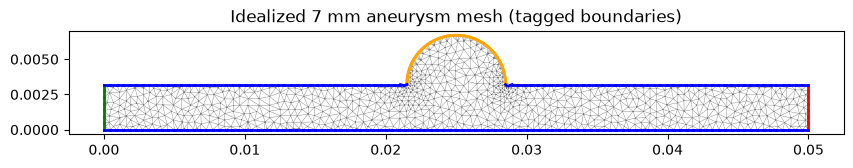

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.triplot(m.p[0], m.p[1], m.t.T, linewidth=0.3, color="gray")
colors = {"inlet": "g", "outlet": "r", "wall_vessel": "b", "wall_sac": "orange"}
for name, facets in m.boundaries.items():
    for f in facets:
        pts = m.p[:, m.facets[:, f]]
        ax.plot(pts[0], pts[1], color=colors[name], linewidth=2)
ax.set_aspect("equal")
ax.set_title("Idealized 7 mm aneurysm mesh (tagged boundaries)")
plt.show()

## Solve the steady Carreau-viscosity flow field

Inlet velocity 47 cm/s, matching the paper's experimental flow rate for
this geometry (Sec. 2.8). Mass conservation (inlet flux == outlet flux) is
checked as a basic sanity diagnostic -- see `tests/test_mechanistic_conservation.py`
for the full validation suite this notebook's checks summarize.

In [4]:
carreau = CarreauParams(mu_inf_pa_s=0.0035, mu_0_pa_s=0.056, lambda_s=3.313, n=0.3568)
flow = solve_steady_flow(tagged_mesh, inlet_velocity_m_s=0.47, carreau=carreau)
print(f"converged={flow.converged}, iterations={flow.n_iterations}, residual={flow.residual:.2e}")

q_in = compute_boundary_flux(flow, "inlet")
q_out = compute_boundary_flux(flow, "outlet")
print(f"flux in={q_in:.6e}, flux out={q_out:.6e}, relative imbalance={abs(q_in + q_out) / abs(q_in):.2e}")

converged=True, iterations=9, residual=5.71e-08
flux in=-1.504000e-03, flux out=1.504000e-03, relative imbalance=6.83e-14


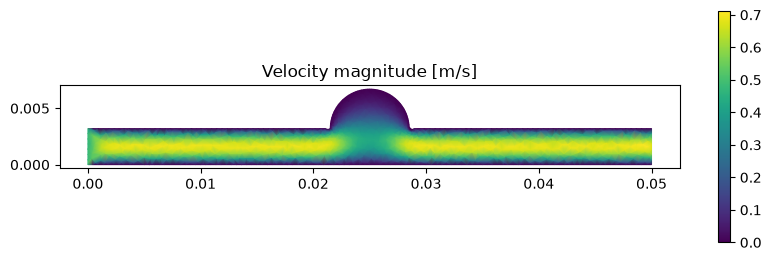

In [5]:
# Velocity magnitude at mesh vertices (P2 nodal dofs coincide with vertices
# for the corner/vertex nodes; this simple slice is sufficient for a quick look).
n_vertices = m.p.shape[1]
ux = flow.u[0 : 2 * n_vertices : 2]
uy = flow.u[1 : 2 * n_vertices : 2]
speed = np.hypot(ux, uy)

fig, ax = plt.subplots(figsize=(10, 3))
tpc = ax.tripcolor(m.p[0], m.p[1], m.t.T, speed, shading="gouraud", cmap="viridis")
ax.set_aspect("equal")
ax.set_title("Velocity magnitude [m/s]")
fig.colorbar(tpc, ax=ax)
plt.show()

## Wall shear rate and its axial gradient (mechanical aggregation trigger)

The paper's key mechanism (Eqs. 6-7): platelet mechanical aggregation is
gated on *negative* axial gradients of wall shear rate,
`d(gamma_w)/dx < 0` (shear decelerating downstream -- e.g. past a neck
into the sac). This reuses `coupled_solver.py`'s own
`_wall_shear_rate_nodal`/`_wall_branches`/`_axial_shear_gradient`
helpers directly (rather than reimplementing the same
projection/branch-split/finite-difference logic here) on the flow field
already solved above -- no new solve needed for this section.

These helpers are prefixed `_` (module-private): they are implementation
details of the coupled solver's per-step loop, not currently part of the
package's public API. Reusing them as-is from a notebook for exploratory
plotting is a reasonable use that doesn't itself require promoting them to
a public API.

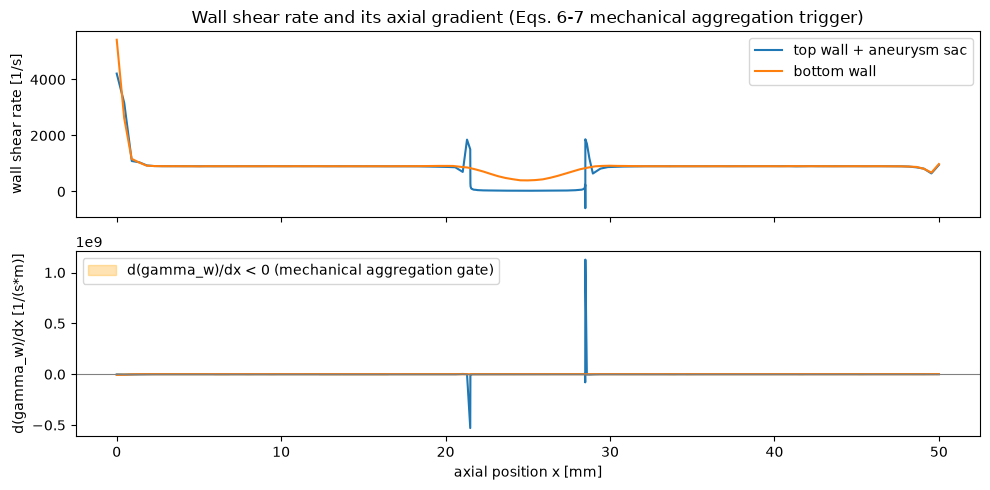

fraction of wall DOFs with negative axial shear gradient (mechanical aggregation gated on): 0.56


In [6]:
from matplotlib.patches import Patch
from skfem import Basis, ElementTriP1

from thrombus_bench.mechanistic.coupled_solver import (
    _axial_shear_gradient,
    _wall_branches,
    _wall_shear_rate_nodal,
)

vessel_diameter_m = geom.vessel_diameter_mm * 1.0e-3
basis_c = Basis(m, ElementTriP1())
top_branch, bottom_branch = _wall_branches(basis_c, vessel_diameter_m)
wall_dofs = np.union1d(top_branch, bottom_branch)

gamma_nodal = _wall_shear_rate_nodal(basis_c, flow)
d_gamma_dx_wall = _axial_shear_gradient(basis_c, wall_dofs, gamma_nodal, top_branch, bottom_branch)
grad_full = np.zeros(basis_c.N)
grad_full[wall_dofs] = d_gamma_dx_wall

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for branch, label in [(top_branch, "top wall + aneurysm sac"), (bottom_branch, "bottom wall")]:
    x_mm = basis_c.doflocs[0, branch] * 1e3
    axes[0].plot(x_mm, gamma_nodal[branch], label=label)
    g = grad_full[branch]
    axes[1].plot(x_mm, g, label=label)
    axes[1].fill_between(x_mm, g, 0.0, where=g < 0, color="orange", alpha=0.3)

axes[0].set_ylabel("wall shear rate [1/s]")
axes[0].set_title("Wall shear rate and its axial gradient (Eqs. 6-7 mechanical aggregation trigger)")
axes[0].legend(loc="best")

axes[1].axhline(0.0, color="gray", linewidth=0.8)
axes[1].set_ylabel("d(gamma_w)/dx [1/(s*m)]")
axes[1].set_xlabel("axial position x [mm]")
axes[1].legend(
    handles=[Patch(color="orange", alpha=0.3, label="d(gamma_w)/dx < 0 (mechanical aggregation gate)")],
    loc="best",
)
plt.tight_layout()
plt.show()

frac_negative = np.mean(grad_full[wall_dofs] < 0)
print(f"fraction of wall DOFs with negative axial shear gradient (mechanical aggregation gated on): {frac_negative:.2f}")

## Transient coupled simulation (short demo run)

Runs `mechanistic.coupled_solver.run_coupled_simulation` on the same
7 mm-diameter mesh built above (`tagged_mesh`), coupling flow, the
9-species CDR system, and the surface ODEs. `end_time_s=0.6`,
`dt_s=0.1` (6 macro steps, one checkpoint per step, flow re-solved every
step) is a short demo window picked to keep this section well under the
notebook's ~30s interactive-runtime budget on CPU -- it is not a run at
the paper's physiological timescale (minutes; that scale is a
`configs/pilot.yaml`-sized batch job, not a notebook cell). See
`tests/test_coupled_solver.py` for the same short-window pattern used in
the test suite.

In [7]:
import time

import yaml

from thrombus_bench.mechanistic.coupled_solver import run_coupled_simulation

with open("../configs/physio_params.yaml") as f:
    physio = yaml.safe_load(f)

t0 = time.time()
history = run_coupled_simulation(
    tagged_mesh, inlet_velocity_m_s=0.47, physio=physio,
    end_time_s=0.6, dt_s=0.1, output_every_n_steps=1, flow_resolve_every_n_steps=1,
)
print(f"ran {len(history.states)} checkpoints in {time.time() - t0:.1f}s")
print(f"thrombin_fibrin_reliable={history.thrombin_fibrin_reliable}")
if not history.thrombin_fibrin_reliable:
    print(
        "NOTE: this run hit the [T]/[FI] concentration_cap at some point during "
        "the loop -- see README.md 'Known limitations' (thrombin/fibrin "
        "calibration is an open, unresolved issue, not a bug fixed in passing). "
        "Treat the [T]/[FI] values plotted below as numerically bounded by that "
        "cap, not as physically meaningful without further recalibration."
    )

ran 6 checkpoints in 5.7s
thrombin_fibrin_reliable=False
NOTE: this run hit the [T]/[FI] concentration_cap at some point during the loop -- see README.md 'Known limitations' (thrombin/fibrin calibration is an open, unresolved issue, not a bug fixed in passing). Treat the [T]/[FI] values plotted below as numerically bounded by that cap, not as physically meaningful without further recalibration.


### `M_at` growth along the wall

Plotted along the top-wall + aneurysm-sac branch specifically (via the
same `_wall_branches` helper reused above), since that's where the
paper's mechanically-triggered growth concentrates (module docstring of
`coupled_solver.py`). `CoupledSimulationHistory.states` holds one
`SurfaceState` per checkpoint with a fixed `wall_dofs` ordering across
the whole run, so the same branch/index mapping applies to every
checkpoint.

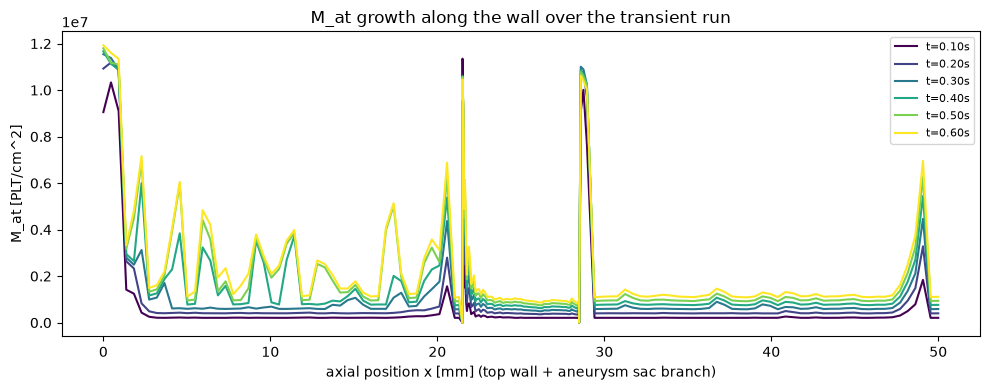

max [FI] per checkpoint [uM]: ['0.00', '14.00', '14.00', '14.00', '14.00', '14.00']


In [8]:
top_branch_run, _ = _wall_branches(history.basis_c, vessel_diameter_m)
x_mm = history.basis_c.doflocs[0, top_branch_run] * 1e3
idx_in_wall_dofs = np.searchsorted(history.states[0].wall_dofs, top_branch_run)

n_states = len(history.states)
fig, ax = plt.subplots(figsize=(10, 4))
for i, state in enumerate(history.states):
    ax.plot(
        x_mm, state.surface.M_at[idx_in_wall_dofs],
        label=f"t={state.time_s:.2f}s", color=plt.cm.viridis(i / max(n_states - 1, 1)),
    )
ax.set_xlabel("axial position x [mm] (top wall + aneurysm sac branch)")
ax.set_ylabel("M_at [PLT/cm^2]")
ax.set_title("M_at growth along the wall over the transient run")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fi_max_per_checkpoint = [state.concentrations["FI"].max() for state in history.states]
print("max [FI] per checkpoint [uM]:", [f"{v:.2f}" for v in fi_max_per_checkpoint])

## `fluid_mask` / `M_at_wall` rasterization sanity check

`data/generate_dataset.py`'s `_run_one_sample` rasterizes the FEM
solution onto a fixed grid for the neural surrogate: `_fluid_mask` flags
which grid cells actually fall inside the vessel+aneurysm domain (the
bounding-box grid contains genuine exterior cells outside the L/T-shaped
domain), and `_rasterize_wall_band` rasterizes `M_at` (defined only on
wall DOFs) into a narrow band around the wall rather than smearing it
across the whole domain like the bulk species fields. Both have unit test
coverage (`tests/test_m_at_wall_rasterization.py`) but no visual sanity
check anywhere else in the repo -- plotted here directly on the same
geometry + run used above.

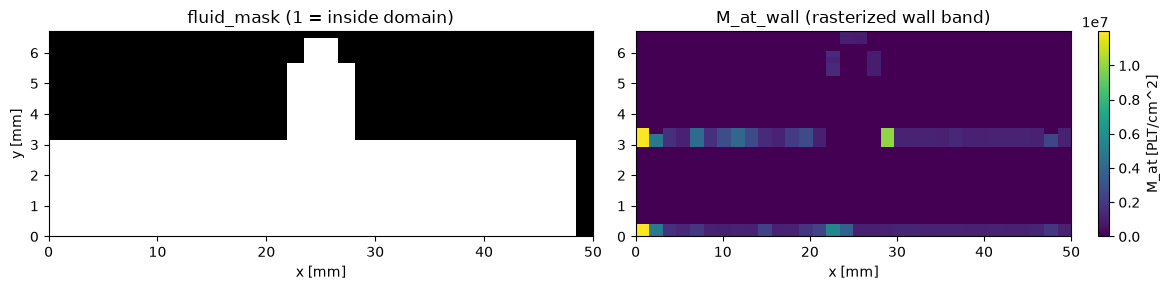

fluid_mask fraction inside domain: 0.51
M_at_wall nonzero fraction (wall-band cells): 0.154


In [9]:
from thrombus_bench.data.generate_dataset import _fluid_mask, _rasterize_wall_band

grid_size = (32, 32)
node_coords = tagged_mesh.mesh.p
final_state = history.states[-1]

fluid_mask = _fluid_mask(node_coords, tagged_mesh.mesh.t, grid_size)
wall_node_coords = history.basis_c.doflocs[:, final_state.wall_dofs]
M_at_wall = _rasterize_wall_band(node_coords, wall_node_coords, final_state.surface.M_at, grid_size)

extent = [
    node_coords[0].min() * 1e3, node_coords[0].max() * 1e3,
    node_coords[1].min() * 1e3, node_coords[1].max() * 1e3,
]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(fluid_mask, origin="lower", cmap="gray", extent=extent, aspect="auto")
axes[0].set_title("fluid_mask (1 = inside domain)")
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")

im = axes[1].imshow(M_at_wall, origin="lower", cmap="viridis", extent=extent, aspect="auto")
axes[1].set_title("M_at_wall (rasterized wall band)")
axes[1].set_xlabel("x [mm]")
fig.colorbar(im, ax=axes[1], label="M_at [PLT/cm^2]")
plt.tight_layout()
plt.show()

print(f"fluid_mask fraction inside domain: {fluid_mask.mean():.2f}")
print(f"M_at_wall nonzero fraction (wall-band cells): {(M_at_wall > 0).mean():.3f}")

## Next steps

Genuinely open items for this notebook / the mechanistic baseline
(everything above is implemented and tested -- see `README.md` "Project
status"; this is not a "not yet implemented" list):

- **Quantitative comparison against the paper's reported thrombus height**
  (Fig. 4a: approx. 6 mm at 120 min for this 7 mm aneurysm) is out of
  reach for an interactive notebook -- it needs a run at physiological
  timescale (minutes, not the ~0.6s demo window above), i.e. a
  `configs/pilot.yaml`-scale batch job, not a notebook cell.
- **Comparison against COMSOL or experimental data** is not available --
  per `README.md` "Known limitations", this project has no access to
  the paper's COMSOL implementation or experimental measurements, only
  the paper text itself; numeric agreement with the paper was never a
  goal (qualitative behavior is).
- The `[T]`/`[FI]` calibration issue flagged above
  (`thrombin_fibrin_reliable`) is an open, unresolved modeling issue --
  see `README.md` "Known limitations" for the current status, not
  something to silently patch over in a notebook run.